In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from pandarallel import pandarallel
from plotly import express as px
from rdkit.Chem import PandasTools
from rdkit.Chem.rdmolfiles import MolFromSmiles, SDMolSupplier
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.ML.Cluster.Butina import ClusterData
from rdkit.rdBase import LogToPythonLogger
from rich.progress import Progress, track
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA, SparsePCA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from tqdm import tqdm
from umap import UMAP, plot

/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effec

In [2]:
from sort_and_slice_ecfp_featuriser import create_sort_and_slice_ecfp_featuriser

In [3]:
LogToPythonLogger()
sns.set(context="notebook", style="white", rc={"figure.figsize": (14, 10)})
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 44 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [4]:
files = {
    # "DrugBank": "/homes/buttensc/Projects/semla-flow/data/unconditional/drugbank/all_structures_3d.csv",
    "DrugBank": "data/04_description/drugbank_approved_3d_desc.csv",
    "GEOM Drugs": "data/04_description/geom_drugs_desc.csv",
    ###
    "EQGAT-diff": "data/04_description/eqgat_100000_predictions_desc.csv",
    "GCDM": "data/04_description/gcdm_100000_predictions_desc.csv",
    "GeoLDM": "data/04_description/geoldm_100000_predictions_desc.csv",
    "FlowMol": "data/04_description/flowmol_100000_predictions_desc.csv",
    "SemlaFlow": "data/04_description/semlaflow_100000_predictions_desc.csv",
    ### PP
    # "EQGAT-diff + PP": "data/04_description/eqgat_100000_predictions_pp_desc.csv",
    # "GCDM + PP": "data/04_description/gcdm_100000_predictions_pp_desc.csv",
    # "GeoLDM + PP": "data/04_description/geoldm_100000_predictions_pp_desc.csv",
    # "FlowMol + PP": "data/04_description/flowmol_100000_predictions_pp_desc.csv",
    # "SemlaFlow + PP": "data/04_description/semlaflow_100000_predictions_pp_desc.csv",
}
dfs = []
for name, file in files.items():
    df = pd.read_csv(file, low_memory=False)
    df["method"] = name
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True).reset_index(drop=True)

In [5]:
cols = ["loads", "sanitizes", "connected", "no_radicals", "all_hydrogens"]
df[cols] = df[cols].astype("boolean")  # .fillna(False)
df["all_hydrogens"] = df["all_hydrogens"] & df["no_radicals"].fillna(True)
cols = ["loads", "sanitizes", "connected", "all_hydrogens"]
df["chemical"] = df[cols].fillna(False).all(axis=1)

In [6]:
# define order of methods
order = [
    "DrugBank",
    "GEOM Drugs",
    # "GEOM Drugs training data",
    # "GEOM Drugs Validation",
    # "GEOM Drugs Testing",
    "EQGAT-diff",
    "FlowMol",
    "GCDM",
    "GeoLDM",
    "SemlaFlow",
    # "",
    # "EQGAT-diff + PP",
    # "FlowMol + PP",
    # "GCDM + PP",
    # "GeoLDM + PP",
    # "SemlaFlow + PP",
    # "DrugBank Approved",
]
df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)

In [7]:
sizes = df.groupby("method", observed=True).size()
sizes

method
DrugBank        2066
GEOM Drugs    301855
EQGAT-diff     93261
FlowMol       100000
GCDM          100000
GeoLDM         83399
SemlaFlow      94926
dtype: int64

In [8]:
# filter on valid smiles
# df = df[df[["connected", "chemical"]].fillna(False).all(axis=1)][["smiles", "method"]]
df = df[df["sanitizes"]]
df = df[df["smiles"].str.len() > 0]
print(len(df))

742187


In [9]:
# TEST
# df = df.groupby("method", observed=True).sample(1000)
sizes = df.groupby("method", observed=True).size()

# Generate molecules

In [10]:
# PandasTools.AddMoleculeColumnToFrame(df, "smiles", "mol", includeFingerprints=False)
df["mol"] = df["smiles"].apply(MolFromSmiles)
df = df.dropna(subset=["mol"])
print(len(df))
# runs 2 min 30 sec

[21:27:01] Conflicting single bond directions around double bond at index 19.
[21:27:01]   BondStereo set to STEREONONE and single bond directions set to NONE.
[21:27:07] Conflicting single bond directions around double bond at index 20.
[21:27:07]   BondStereo set to STEREONONE and single bond directions set to NONE.
[21:27:09] Conflicting single bond directions around double bond at index 17.
[21:27:09]   BondStereo set to STEREONONE and single bond directions set to NONE.


742187


### Define training set

In [11]:
# # training_set = df_resampled["mol"].apply(lambda x: x is not None)
# training_set = df["mol"].apply(lambda x: x is not None)
# # training_set = df["source"] == "DrugBank"
# df_train = df[training_set]

In [12]:
# df_train = df.sample(frac=1).groupby("method").head(2500)
df_train = df

### Create fingerprint

In [13]:
dims = 2048
ecfp_featuriser = create_sort_and_slice_ecfp_featuriser(
    mols_train=df_train["mol"],
    max_radius=2,
    pharm_atom_invs=False,
    bond_invs=True,
    chirality=False,
    sub_counts=True,
    vec_dimension=dims,  # explore 1024, 2048
)


def featuriser(mol):
    # unit8 has range 0-255
    return ecfp_featuriser(mol).astype(np.uint8)


# 2 sec

Number of compounds in molecular training set =  742187
Number of unique circular substructures with the specified parameters in molecular training set =  1639921


In [14]:
df["fp"] = df["mol"].apply(featuriser)
# runs 24 min

In [20]:
fingerprints = np.stack(df["fp"])
# np.save(f"fps_{dims}.npy", fingerprints)

In [22]:
# fingerprints = np.load(f"fps_{dims}.npy").astype(np.int8)
# df["fp"] = fingerprints.tolist()
print("max", fingerprints.max())
print("shape", fingerprints.shape)
print("all zeros", (fingerprints.sum(axis=1) == 0).sum())

max 35
shape (742187, 2048)
all zeros 6


# Cluster

In [23]:
df["in_training"] = False
df.loc[df_train.index, "in_training"] = True
print(df["in_training"].sum())

742187


In [24]:
fp_sel = fingerprints[df.in_training]
distances = pdist(fp_sel, metric="cityblock")
distances.shape
# 4 minutes

MemoryError: Unable to allocate 2.00 TiB for an array with shape (275420400391,) and data type float64

In [ ]:
num_counts = fp_sel.sum(axis=1)
numerator = squareform(distances)
denominator = num_counts[:, None] + num_counts[None, :]
distances_normed = squareform(np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0))

<Axes: ylabel='Count'>

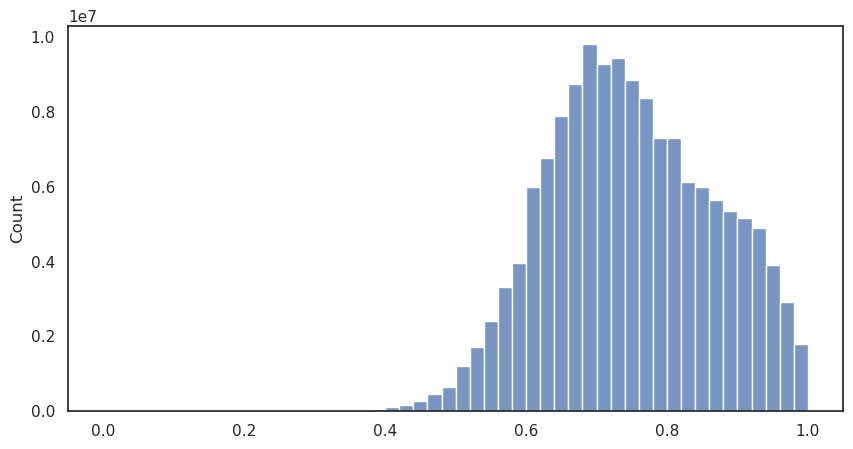

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(distances_normed, bins=50)

In [ ]:
dist_thresh = 0.4
reordering = False
n_points = df["in_training"].sum()

clusters = ClusterData(distances_normed, nPts=n_points, isDistData=True, distThresh=dist_thresh, reordering=reordering)
len(clusters)

3091

In [ ]:
member_lookup = {member: cluster_number for cluster_number, cluster in enumerate(clusters) for member in cluster}
centroids = [cluster[0] for cluster in clusters]

df_clustered = pd.DataFrame()
df_clustered["idx"] = range(df["in_training"].sum())
df_clustered["cluster"] = df_clustered["idx"].map(member_lookup)
df_clustered["centroid"] = df_clustered["cluster"].map(lambda i: centroids[i])
# df_clustered.to_csv("clustered.csv", index=False)
df_clustered

,idx,cluster,centroid
0,0,16,13941
1,1,153,12682
2,2,45,14889
3,3,388,5301
4,4,50,14167
...,...,...,...
17061,17061,494,13067
17062,17062,525,16949
17063,17063,315,12625
17064,17064,762,17064


### Dimension reduction

Measuring difference between bit-wise or count-wise fingerprints. 
- Manhatten: L1(f1, f2) = counts how many features are different 



In [56]:
# X = np.asarray(df.loc[df_train.index, "fp"].tolist())
# X = fp_sel[centroids]
X = fp_sel

# model = PCA(n_components=2)
# model = SparsePCA(n_components=2)

# model = TSNE(n_components=2, perplexity=30, metric="manhattan")

# reducer = UMAP(metric="correlation", min_dist=1.0, spread=1.0)
# reducer = UMAP(metric="correlation", min_dist=0.5, spread=1.0)
# reducer = UMAP(metric="cosine", min_dist=1.0, spread=1.0)
# reducer = UMAP(metric="cosine", min_dist=0.5, spread=1.0)
# model = UMAP(metric="dice", min_dist=1.0, spread=1.0)
model = UMAP(metric="manhattan", min_dist=0.2, spread=0.7)
# model = UMAP(metric="manhattan", min_dist=0.1, spread=0.5)

model.fit(X)
# umap 30 seconds
# tsne

/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisatio

UMAP(metric='manhattan', min_dist=0.2, spread=0.7, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [57]:
# data = model.transform(np.asarray(fp_sel.tolist()))
# umap 3 min

# data = model.fit_transform(np.asarray(fp_sel.tolist()))
# tsne 1 min

# ALL
# umap
data = model.transform(fingerprints)

/data/pegasus/buttensc/Storage/Applications/miniforge/envs/evaluation/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [58]:
df_plot = pd.DataFrame(data, columns=["x", "y"])
df_plot["method"] = df[df.in_training]["method"].reset_index(drop=True)
df_plot

,x,y,method
0,2.107214,5.550782,DrugBank
1,4.692585,4.795115,DrugBank
2,2.823664,6.739971,DrugBank
3,-3.916739,-0.194711,DrugBank
4,3.385698,7.349459,DrugBank
...,...,...,...
742182,-4.131282,-0.173404,SemlaFlow
742183,-2.092645,1.716018,SemlaFlow
742184,-1.105911,3.230944,SemlaFlow
742185,-3.029054,-0.069417,SemlaFlow


In [59]:
df_plot.to_csv("umap_shown_4.csv", index=False)

In [60]:
# define order of methods
order = [
    "DrugBank",
    "GEOM Drugs",
    # "GEOM Drugs training data",
    # "GEOM Drugs Validation",
    # "GEOM Drugs Testing",
    "EQGAT-diff",
    "FlowMol",
    "GCDM",
    "GeoLDM",
    "SemlaFlow",
    # "",
    # "EQGAT-diff + PP",
    # "FlowMol + PP",
    # "GCDM + PP",
    # "GeoLDM + PP",
    # "SemlaFlow + PP",
    # "DrugBank Approved",
]
df_plot["method"] = pd.Categorical(df_plot["method"], categories=order, ordered=True)

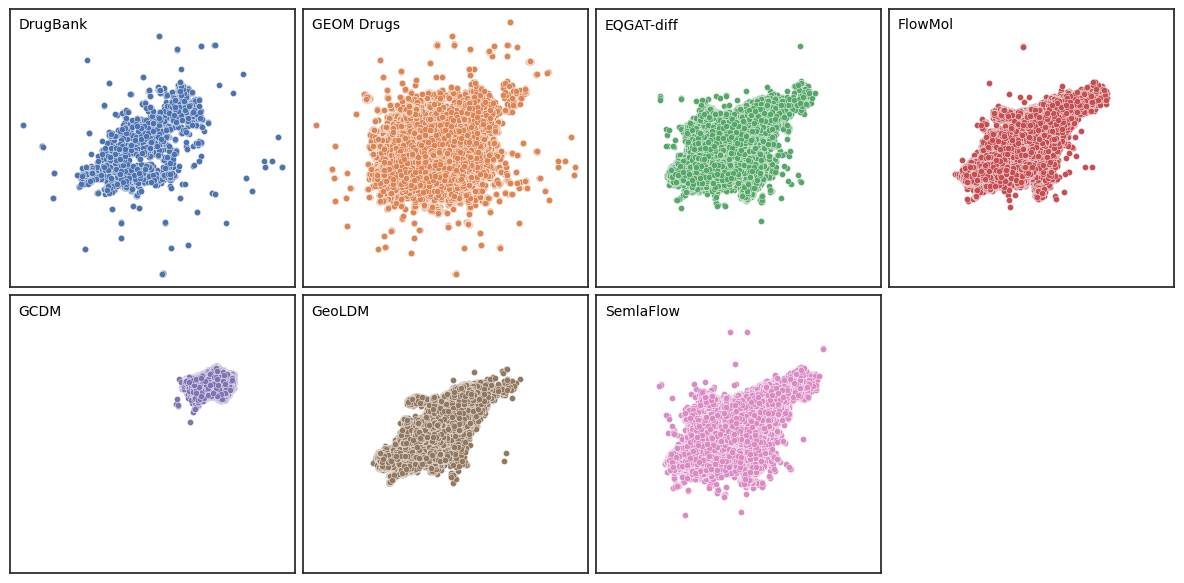

In [61]:
# facetgrid with seaborn scatter, different color each
# col_order = order[:2] + order[-1:] + order[2:-1]
col_order = order
hue_order = order
g = sns.FacetGrid(
    df_plot,
    col="method",
    hue="method",
    col_wrap=4,
    despine=False,
    margin_titles=False,
    height=3,
    aspect=1,
    col_order=col_order,
    hue_order=hue_order,
)
g.map(sns.scatterplot, "x", "y", s=20, linewidth=0.3, alpha=1.0, edgecolor="white")
g.figure.subplots_adjust(wspace=0, hspace=0)
for ax in g.axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.text(0.03, 0.97, ax.get_title().split("=")[1].strip(), transform=ax.transAxes, ha="left", va="top", fontsize=10, color="black")
    ax.set_title("")
# g.add_legend(title="", loc="upper right", bbox_to_anchor=(0.9, 0.7))
# remove spine
# sns.despine(left=True, bottom=True)
plt.tight_layout(h_pad=0.5, w_pad=0.5)
plt.savefig("plots/umap_4.png", dpi=1200)